# Silver EDA — what you actually have

`data/silver/compliance_chunks.parquet` — 1519 chunks × 7 cols. No GPU, no pixi needed. Works in Colab.

**Covers:** schema → distribution → chunk/token stats → domain rollup → gaps & quality. 5 min.

> Data: [Releases](https://github.com/dataengineergaurav/open-regulatory-corpus/releases) or `load_dataset("GauravGurjar/open-regulatory-corpus")`

In [1]:
import pandas as pd
from pathlib import Path

parquet = Path("../data/silver/compliance_chunks.parquet")
if not parquet.exists():
    parquet = Path("data/silver/compliance_chunks.parquet")
if not parquet.exists():
    # Colab fallback: HF
    from datasets import load_dataset
    ds = load_dataset("GauravGurjar/open-regulatory-corpus")["train"]
    df = ds.to_pandas()
else:
    df = pd.read_parquet(parquet)
print(f"rows={len(df)} cols={list(df.columns)}")
df.head(2)

rows=1519 cols=['framework_id', 'chunk_id', 'text', 'source', 'kind', 'token_est', 'sha256']


,framework_id,chunk_id,text,source,kind,token_est,sha256
0,AU-PRIVACY-AI,AU-PRIVACY-AI-0,- On this page Top five takeaways - Privacy ob...,data/bronze/latest/raw/AU-PRIVACY-AI.html,html,510.72,39ac04be139d01b8c974ddf6fe0bd42c0aaeb4b8b3286f...
1,AU-PRIVACY-AI,AU-PRIVACY-AI-1,"policy. - As a matter of best practice, the OA...",data/bronze/latest/raw/AU-PRIVACY-AI.html,html,510.72,39ac04be139d01b8c974ddf6fe0bd42c0aaeb4b8b3286f...


In [2]:
# schema + dtypes + nulls — trust but verify
print(df.dtypes.to_string())
print("\nnulls:", df.isna().sum().to_dict())
print("\nunique frameworks:", df.framework_id.nunique())
print("unique sha256 (docs):", df.sha256.nunique())
print("\nsample chunk_id:", df.chunk_id.iloc[:3].tolist())
df[["framework_id","chunk_id","kind","token_est"]].head(5)

framework_id     object
chunk_id         object
text             object
source           object
kind             object
token_est       float64
sha256           object

nulls: {'framework_id': 0, 'chunk_id': 0, 'text': 0, 'source': 0, 'kind': 0, 'token_est': 0, 'sha256': 0}

unique frameworks: 54
unique sha256 (docs): 54

sample chunk_id: ['AU-PRIVACY-AI-0', 'AU-PRIVACY-AI-1', 'AU-PRIVACY-AI-2']


,framework_id,chunk_id,kind,token_est
0,AU-PRIVACY-AI,AU-PRIVACY-AI-0,html,510.72
1,AU-PRIVACY-AI,AU-PRIVACY-AI-1,html,510.72
2,AU-PRIVACY-AI,AU-PRIVACY-AI-2,html,510.72
3,AU-PRIVACY-AI,AU-PRIVACY-AI-3,html,510.72
4,AU-PRIVACY-AI,AU-PRIVACY-AI-4,html,510.72


In [3]:
# distribution — where the mass is
vc = df.framework_id.value_counts()
print(vc.head(15).to_string())
print(f"\ntop 3 = {vc.head(3).sum()} / {len(df)} ({vc.head(3).sum()/len(df):.0%})")
print(f"single-chunk frameworks: {(vc==1).sum()} →", vc[vc==1].index.tolist())

# kind split (pdf vs html extraction)
print("\nkind:", df.kind.value_counts().to_dict())
print("\nframeworks with pdf suffix (secondary PDFs):", [x for x in vc.index if "_pdf" in x][:8])

framework_id
CJIS-6.1_pdf      462
IRS-1075_pdf1     222
SOX_pdf1          155
CCPA-CPRA_pdf2    121
FDA-AI-MD          80
SOX_pdf2           67
EAR                52
FERPA              39
AU-PRIVACY-AI      38
OMB-M25-21         29
NIST-CSF2          28
EAR_pdf2           20
SG-MODEL-AI        19
OMB-M25-22         15
ONC-HTI1_pdf2      14

top 3 = 839 / 1519 (55%)
single-chunk frameworks: 10 → ['FRB-MRM-2026', 'NYDFS-500', 'NYC-LL144', 'FEDRAMP', 'NIST-AI-RMF', 'OWASP-LLM-2026', 'SECTION-508', 'NIST-800-171', 'TX-TRAIGA', 'IRS-1075']

kind: {'pdf': 1236, 'html': 283}

frameworks with pdf suffix (secondary PDFs): ['CJIS-6.1_pdf', 'IRS-1075_pdf1', 'SOX_pdf1', 'CCPA-CPRA_pdf2', 'SOX_pdf2', 'EAR_pdf2', 'ONC-HTI1_pdf2', 'ONC-HTI1_pdf1']


In [4]:
# domain rollup — 38 frameworks → 5 domains (see README)
domains = {
    "AI Governance": ["NIST-AI-RMF","NIST-AI-600-1","EU-AI-ACT","OMB-M25-21","OMB-M25-22","OWASP-LLM-2026","CO-AI","TX-TRAIGA","SG-MODEL-AI"],
    "Privacy & Data": ["GDPR","CCPA-CPRA","FERPA","COPPA","UK-DP-AI","BR-LGPD","AU-PRIVACY-AI","DOJ-DSP"],
    "Cybersecurity": ["NIST-CSF2","NIST-800-53","NIST-800-171","FEDRAMP","CMMC","CJIS-6.1","IRS-1075"],
    "Financial": ["SOX","GLBA","NYDFS-500","FRB-MRM-2026","ECOA-REG-B","NAIC-AI"],
    "Health/Access/Trade": ["HIPAA","HHS-PART2","SECTION-508","ONC-HTI1","FDA-AI-MD","NYC-LL144","IL-AIVIA","EAR"],
}
# expand to include _pdf suffixes
def domain_of(fid):
    stem = fid.split("_pdf")[0]
    for d, members in domains.items():
        if stem in members:
            return d
    return "Other"
df["domain"] = df.framework_id.apply(domain_of)
print(df.domain.value_counts().to_string())
print("\nOther (should be 0):", df[df.domain=="Other"].framework_id.unique().tolist()[:5])
# show per-domain top framework
for d in domains:
    sub = df[df.domain==d]
    top = sub.framework_id.value_counts().head(1)
    print(f"{d:20} {len(sub):4} chunks → top {top.index[0]} ({top.iloc[0]})")


domain
Cybersecurity          734
Financial              276
Privacy & Data         219
Health/Access/Trade    206
AI Governance           84

Other (should be 0): []
AI Governance          84 chunks → top OMB-M25-21 (29)
Privacy & Data        219 chunks → top CCPA-CPRA_pdf2 (121)
Cybersecurity         734 chunks → top CJIS-6.1_pdf (462)
Financial             276 chunks → top SOX_pdf1 (155)
Health/Access/Trade   206 chunks → top FDA-AI-MD (80)


        words  token_est
count  1519.0     1519.0
mean    377.8      502.5
std      37.4       49.7
min      52.0       69.2
25%     384.0      510.7
50%     384.0      510.7
75%     384.0      510.7
max     384.0      510.7

words p95: 384.0  | token_est p95: 510.7
short chunks (<100 words): 7
long chunks (>500 words): 0

 framework_id
NIST-AI-RMF      384.0
FEDRAMP          384.0
CJIS-6.1_pdf     384.0
FDA-AI-MD        383.0
SOX_pdf1         383.0
EAR              383.0
IRS-1075_pdf1    383.0
UK-DP-AI         383.0


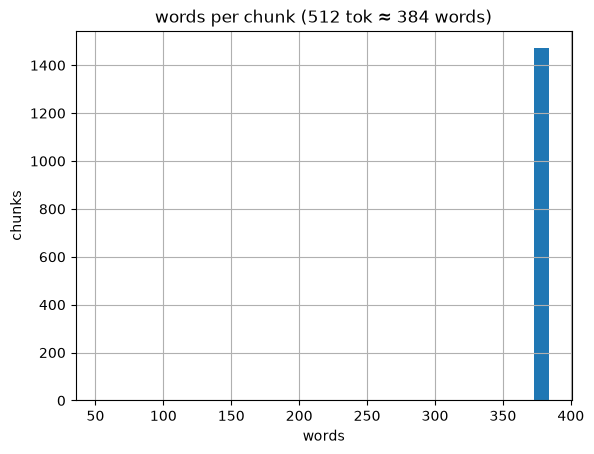

In [5]:
# chunk & token stats — is 512/50 sane?
df["words"] = df.text.str.split().str.len()
print(df[["words","token_est"]].describe().round(1).to_string())
print("\nwords p95:", df.words.quantile(0.95), " | token_est p95:", round(df.token_est.quantile(0.95),1))
print("short chunks (<100 words):", (df.words < 100).sum())
print("long chunks (>500 words):", (df.words > 500).sum())

# histogram — pandas plot if matplotlib available, else counts
try:
    ax = df.words.hist(bins=30)
    ax.set_title("words per chunk (512 tok ≈ 384 words)")
    ax.set_xlabel("words"); ax.set_ylabel("chunks")
except Exception as e:
    print("hist fallback:", df.words.value_counts(bins=5).to_string())

# per-framework avg length — outliers?
print("\n", df.groupby("framework_id").words.mean().sort_values(ascending=False).head(8).round(0).to_string())


In [6]:
# gaps & quality — what's missing and why (see docs/DATA_PIPELINE.md)
expected_38 = [f for v in domains.values() for f in v]
present_stems = set(df.framework_id.str.split("_pdf").str[0].unique())
missing = [f for f in expected_38 if f not in present_stems]
print(f"expected 38 stems, present {len(present_stems)}, missing {len(missing)}:")
print(missing)
print("\n→ WAF/nav filtered (0 chunks): GDPR, EU-AI-ACT, HIPAA, CMMC, HHS-PART2, IL-AIVIA, BR-LGPD — see Troubleshooting")

# dedup sanity: sha256 unique == docs (54) vs rows (1519)
print(f"\nsha256 unique: {df.sha256.nunique()} docs, rows: {len(df)}, avg chunks/doc: {len(df)/df.sha256.nunique():.1f}")
# any duplicate chunk_id?
print("dup chunk_id:", df.chunk_id.duplicated().sum())
# token_est ≈ words*1.33?
print("token_est / words median:", (df.token_est/df.words).median().round(2))


expected 38 stems, present 31, missing 7:
['EU-AI-ACT', 'GDPR', 'BR-LGPD', 'CMMC', 'HIPAA', 'HHS-PART2', 'IL-AIVIA']

→ WAF/nav filtered (0 chunks): GDPR, EU-AI-ACT, HIPAA, CMMC, HHS-PART2, IL-AIVIA, BR-LGPD — see Troubleshooting

sha256 unique: 54 docs, rows: 1519, avg chunks/doc: 28.1
dup chunk_id: 0
token_est / words median: 1.33


## Next
- `03_silver_analysis.ipynb` — cookbook: filter, TF-IDF search, cross-framework compare, export for RAG.
- Replace `token_est` with real tokenizer (`tiktoken`) when you need exact counts.
- Gaps are features: track `missing` across releases to measure WAF recovery.